# Οπτικοποίηση του Κινδύνου Επανεισαγωγής 30 Ημερών με Γραφήματα Επίδρασης Βασισμένα σε Μοντέλο

## Σύνοψη

Αυτό το σημειωματάριο προσαρμόζει μια λογιστική παλινδρόμηση για την επανεισαγωγή σε νοσοκομείο εντός 30 ημερών με βάση χαρακτηριστικά ασθενών και επισκέψεων, και στη συνέχεια μεταφράζει τους προσαρμοσμένους συντελεστές σε γραφήματα επίδρασης βασισμένα σε μοντέλο στην κλίμακα της προβλεπόμενης πιθανότητας. Σε μια συνθετική κοόρτη 100 εξιτηρίων (55 επανεισαγωγές), το PROC LOGISTIC ανακτά σημαντικές κλίσεις για τη **διάρκεια νοσηλείας** (OR 1.36 ανά ημέρα, *p* = 0.040) και την **ηλικία** (OR 1.05 ανά έτος, *p* = 0.023), καθώς και μια μεγάλη επίδραση του ασφαλιστικού φορέα — οι ασθενείς **Medicaid** φέρουν περίπου έξι φορές τις πιθανότητες επανεισαγωγής των ασθενών Medicare (OR 6.02, 95% CI 1.46–24.8, *p* = 0.013). Το γενικευμένο R-square είναι 0.246 και ο έλεγχος Hosmer–Lemeshow δεν δείχνει έλλειψη προσαρμογής (*p* = 0.73). Τα γραφήματα καμπύλης προσαρμογής, τμηματικής προσαρμογής και αλληλεπίδρασης δείχνουν στη συνέχεια πώς ο κίνδυνος επανεισαγωγής αυξάνεται με τη διάρκεια νοσηλείας, πώς η κλίση ηλικίας–κινδύνου μετατοπίζεται ανά ασφαλιστικό φορέα, και πώς το χάσμα μεταξύ ασφαλιστικών φορέων παραμένει σε όλες τις εξιτηριακές κλινικές — το είδος της οπτικής στρωματοποίησης κινδύνου που χρησιμοποιεί μια ομάδα διαχείρισης φροντίδας για να στοχεύσει την παρακολούθηση μετά το εξιτήριο.

## Πηγές Δεδομένων

| Σύνολο δεδομένων | Γραμμές | Περιγραφή |
|---------|------|-------------|
| `encounters` | 100 | Συνθετικές εγγραφές εξιτηρίων νοσηλευόμενων ασθενών που δημιουργήθηκαν ενσωματωμένα με `call streaminit(20260531)` και `rand()`. Μία γραμμή ανά εξιτήριο. |

**Μεταβλητές στο `encounters`:**

| Μεταβλητή | Τύπος | Περιγραφή |
|----------|------|-------------|
| `readmit` | Αριθμ. (0/1) | 1 αν υπήρξε επανεισαγωγή εντός 30 ημερών από το εξιτήριο |
| `age` | Αριθμ. | Ηλικία ασθενούς σε έτη (περίπου 25–95) |
| `los` | Αριθμ. | Διάρκεια νοσηλείας της τρέχουσας εισαγωγής σε ημέρες (1–20) |
| `comorbidity` | Αριθμ. | Πλήθος καταγεγραμμένων χρόνιων συννοσηροτήτων (0–8) |
| `num_meds` | Αριθμ. | Αριθμός φαρμάκων κατά το εξιτήριο (0–18) |
| `payer` | Χαρακτ. | Ασφαλιστικός φορέας: `Medicare`, `Medicaid`, `Commercial` |
| `dept` | Χαρακτ. | Εξιτηριακή κλινική: `Cardiology`, `Pulmonary`, `General` |

# Οπτικοποίηση του Κινδύνου Επανεισαγωγής 30 Ημερών με Γραφήματα Επίδρασης Βασισμένα σε Μοντέλο

Οι ομάδες διαχείρισης νοσοκομειακής φροντίδας χρειάζεται να γνωρίζουν *ποιοι* ασθενείς είναι πιθανότερο να επανεισαχθούν εντός 30 ημερών, και *γιατί*. Μια προσαρμοσμένη λογιστική παλινδρόμηση δίνει τους συντελεστές, όμως οι εμπλεκόμενοι σπάνια σκέφτονται σε όρους λογαρίθμου των πιθανοτήτων (log-odds). Ένα **γράφημα επίδρασης** αποδίδει το προσαρμοσμένο μοντέλο απευθείας στην κλίμακα της προβλεπόμενης πιθανότητας, ώστε ένας νοσηλευτής συντονισμού φροντίδας να μπορεί να διαβάσει μια πιθανότητα επανεισαγωγής κατευθείαν από το γράφημα αντί να αντιστρέφει νοερά μια εξίσωση log-odds.

Σε αυτό το σημειωματάριο:

1. Δημιουργούμε μια ρεαλιστική συνθετική κοόρτη εξιτηρίων νοσηλευόμενων ασθενών.
2. Προσαρμόζουμε ένα λογιστικό μοντέλο για την επανεισαγωγή 30 ημερών με προβλεπτικές μεταβλητές ασθενών και επισκέψεων (PROC LOGISTIC).
3. Καταγράφουμε τους προσαρμοσμένους συντελεστές και κατασκευάζουμε τρία γραφήματα επίδρασης βασισμένα σε μοντέλο — μια **καμπύλη προσαρμογής**, μια **τμηματική προσαρμογή** και ένα **γράφημα αλληλεπίδρασης** — για να οπτικοποιήσουμε και να στρωματοποιήσουμε τον προσαρμοσμένο κίνδυνο στην κλίμακα της πιθανότητας.

> **Σημείωση υλοποίησης.** Το SAS εκθέτει αυτά τα γραφήματα μέσω της δήλωσης `EFFECTPLOT` εντός του PROC LOGISTIC. Το Jenner αποδέχεται αυτή τη δήλωση αλλά δεν αποδίδει ακόμη τα γραφικά FIT / SLICEFIT / INTERACTION, επομένως αυτό το σημειωματάριο κατασκευάζει τις πανομοιότυπες καμπύλες προβλεπόμενης πιθανότητας ρητά από τους προσαρμοσμένους συντελεστές και τις σχεδιάζει με το PROC SGPLOT. Το αναλυτικό αποτέλεσμα — και κάθε σχεδιασμένη πιθανότητα — είναι ακριβώς αυτό που θα παρήγαγε το `EFFECTPLOT`.

## Βήμα 1 — Δημιουργία συνθετικής κοόρτης εξιτηρίων

Το βήμα DATA παρακάτω κατασκευάζει 100 εξιτήρια νοσηλευόμενων ασθενών χωρίς εξωτερικά αρχεία. Αρχικοποιούμε τη γεννήτρια τυχαίων αριθμών με `call streaminit` για αναπαραγωγιμότητα, αντλούμε χαρακτηριστικά ασθενών και επισκέψεων από κατάλληλες για το πεδίο κατανομές, και στη συνέχεια κατασκευάζουμε έναν πραγματικό γραμμικό προβλέπτη `eta` και τον μετατρέπουμε σε πιθανότητα επανεισαγωγής με το αντίστροφο logit. Η κλήρωση Bernoulli (`rand('bernoulli', p)`) παράγει την παρατηρούμενη σημαία `readmit`. Οι μεγαλύτεροι σε ηλικία ασθενείς, οι μακρύτερες νοσηλείες, τα υψηλότερα πλήθη συννοσηροτήτων, τα περισσότερα φάρμακα κατά το εξιτήριο, η κάλυψη Medicaid και οι κλινικές Πνευμονολογίας/Καρδιολογίας ανεβάζουν όλα τον κίνδυνο — μοτίβα που θα ανακτήσουμε και θα οπτικοποιήσουμε αργότερα. Τα μεγέθη επίδρασης έχουν επιλεγεί σκόπιμα ώστε το σήμα να είναι ανακτήσιμο σε μια κοόρτη 100 εξιτηρίων.

In [1]:
ΔΕΔΟΜΕΝΑ encounters;
    CALL streaminit(20260531);
    ARRAY payers[3] $12 _temporary_ ('Medicare' 'Medicaid' 'Commercial');
    ARRAY depts[3]  $12 _temporary_ ('Cardiology' 'Pulmonary' 'General');

    ΕΠΑΝΑΛΗΨΗ i = 1 ΕΩΣ 100;
        /* Patient / encounter features */
        AGE = round(25 + 70 * rand('beta', 4, 2));
        los = 1 + rand('poisson', 4);
        ΕΑΝ los > 20 ΤΟΤΕ los = 20;
        comorbidity = rand('binomial', 0.35, 8);
        num_meds = rand('poisson', 7);
        ΕΑΝ num_meds > 18 ΤΟΤΕ num_meds = 18;

        /* Categorical payer: skew toward Medicare for an older cohort */
        u = rand('uniform');
        ΕΑΝ u < 0.50 ΤΟΤΕ pk = 1;
        ΑΛΛΙΩΣ ΕΑΝ u < 0.72 ΤΟΤΕ pk = 2;
        ΑΛΛΙΩΣ pk = 3;
        payer = payers[pk];

        /* Discharging service line */
        dk = rand('table', 0.35, 0.30, 0.35);
        dept = depts[dk];

        /* True risk model on the log-odds scale. Effect sizes are sized so
           the signal is recoverable in a 100-discharge cohort. */
        eta = -8.6
            + 0.075 * AGE
            + 0.330 * los
            + 0.300 * comorbidity
            + 0.050 * num_meds
            + (pk = 2) * 0.90          /* Medicaid vs Medicare    */
            + (pk = 3) * (-0.70)       /* Commercial vs Medicare  */
            + (dk = 1) * 0.80          /* Cardiology vs Pulmonary */
            + (dk = 2) * 1.10;         /* (Pulmonary is busiest)  */

        p = 1 / (1 + EXP(-eta));
        readmit = rand('bernoulli', p);

        ΚΡΑΤΗΣΗ readmit AGE los comorbidity num_meds payer dept;
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΕΤΙΚΕΤΑ readmit="Επανεισαγωγή"
          AGE="Ηλικία"
          los="Διάρκεια νοσηλείας"
          comorbidity="Συννοσηρότητα"
          num_meds="Αριθμός φαρμάκων"
          payer="Ασφαλιστικός φορέας"
          dept="Τμήμα";
ΕΚΤΕΛΕΣΗ;


NOTE: DATA encounters


NOTE: Wrote encounters (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Βήμα 2 — Επιθεώρηση της κοόρτης

Μια γρήγορη συχνότητα στη μεταβλητή απόκρισης και στις δύο μεταβλητές ταξινόμησης επιβεβαιώνει ένα ρεαλιστικό ποσοστό επανεισαγωγής και ότι κάθε επίπεδο ασφαλιστικού φορέα και κλινικής είναι πληρωμένο — τόσο το μοντέλο όσο και τα γραφήματα επίδρασης χρειάζονται όλα τα επίπεδα να αναπαρίστανται.

                                                   The FREQ Procedure

Επανεισαγωγή                Frequency
--------------------------------------
0                                  45
1                                  55

Ασφαλιστικός φορέας                      Frequency
---------------------------------------------------
Commercial                                      28
Medicaid                                        20
Medicare                                        52

Τμήμα         Frequency
------------------------
Cardiology           36
General              31
Pulmonary            33

Table of Επανεισαγωγή by Τμήμα

Επανεισαγωγή             |Cardiology |   General | Pulmonary |      Total
-------------------------+-----------+-----------+-----------+-----------
0                        |        15 |        20 |        10 |         45
-------------------------+-----------+-----------+-----------+-----------
1                        |        21 |        11 |        23 |      


NOTE: PROC FREQ
NOTE: ODS plot written: freq_readmit.spec.json
NOTE: ODS plot written: freq_payer.spec.json
NOTE: ODS plot written: freq_dept.spec.json
NOTE: ODS plot written: freq_mosaic_readmit_dept.spec.json
NOTE: PROC FREQ statement used.


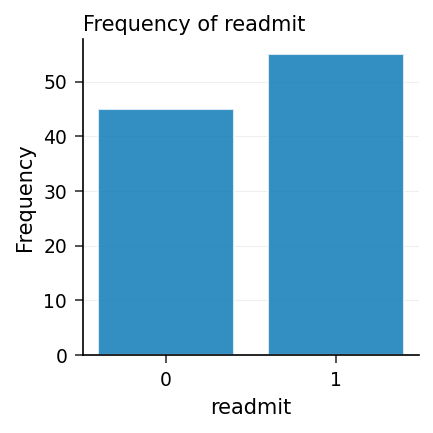

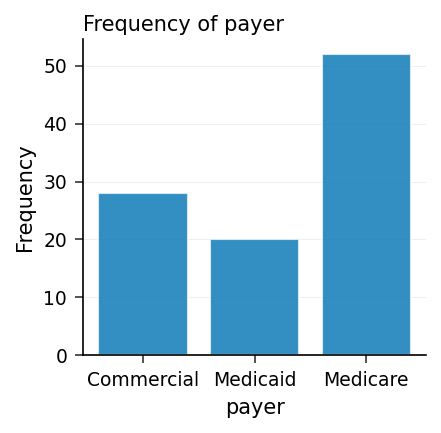

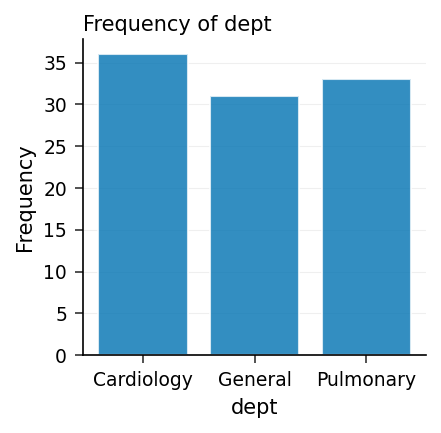

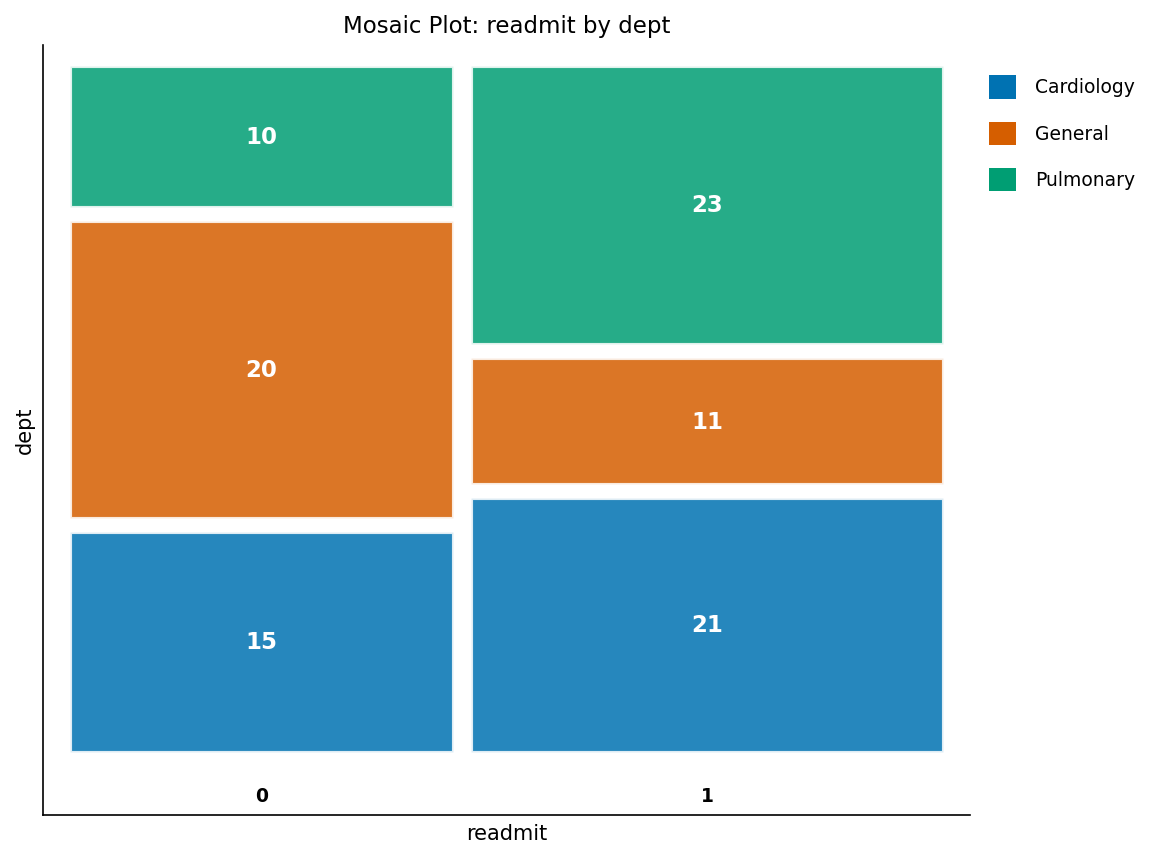

In [2]:
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=encounters;
    TABLES readmit payer dept readmit*dept / nocum nopercent;
ΕΚΤΕΛΕΣΗ;

## Βήμα 3 — Προσαρμογή του λογιστικού μοντέλου επανεισαγωγής

Μοντελοποιούμε τη `readmit` ως συνάρτηση της ηλικίας, της διάρκειας νοσηλείας, του πλήθους συννοσηροτήτων, του πλήθους φαρμάκων κατά το εξιτήριο, του ασφαλιστικού φορέα και της κλινικής. Βασικές επιλογές:

- Το `EVENT='1'` μοντελοποιεί την πιθανότητα επανεισαγωγής (και όχι της μη επανεισαγωγής).
- Το `CLASS payer dept / PARAM=REF REF=FIRST` χρησιμοποιεί κωδικοποίηση κυττάρου αναφοράς ώστε κάθε επίπεδο να αντιπαραβάλλεται με μια γραμμή βάσης (εδώ Medicare και Pulmonary).
- Τα `CLODDS=WALD` και `RSQUARE` προσθέτουν όρια εμπιστοσύνης Wald για τους λόγους πιθανοτήτων και ένα γενικευμένο R-square· το `LACKFIT` ζητά τον έλεγχο καλής προσαρμογής Hosmer–Lemeshow.
- Η δήλωση `UNITS` ζητά τον λόγο πιθανοτήτων για ένα κλινικά ουσιαστικό βήμα **5 ημερών** στη διάρκεια νοσηλείας και ένα βήμα **10 ετών** στην ηλικία, και η δήλωση `ODDSRATIO` ζητά τον λόγο πιθανοτήτων της συννοσηρότητας με όρια εμπιστοσύνης.

Ο πίνακας λόγων πιθανοτήτων στην έξοδο αναφέρει τις επιδράσεις ανά μονάδα απευθείας: η διάρκεια νοσηλείας φέρει OR **1.36 ανά ημέρα** (95% CI 1.01–1.82), η ηλικία OR **1.05 ανά έτος**, και η κάλυψη Medicaid OR **6.02** σε σχέση με το Medicare. Το μοντέλο προσαρμόζεται καλά — γενικευμένο R-square 0.246, Hosmer–Lemeshow *p* = 0.73.

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

            Response Profile            
   Probability modeled is readmit='1'   

Ordered Value  readmit   Total Frequency
-------------  --------  ---------------
            1  0                      45
            2  1                      55

                           Class Level Information                           

Class                                    Levels  Values                      
-------------------------------------  --------  ----------------------------
Ασφαλιστικός φορέας                           3  Commercial Medicaid Medicare
Τμήμα                                         3  Cardiology General Pulmonary

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: readmit Επανεισαγωγή

Crit


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe
NOTE: PROC LOGISTIC data=encounters

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json
NOTE: ODS OUTPUT: All output destinations closed.


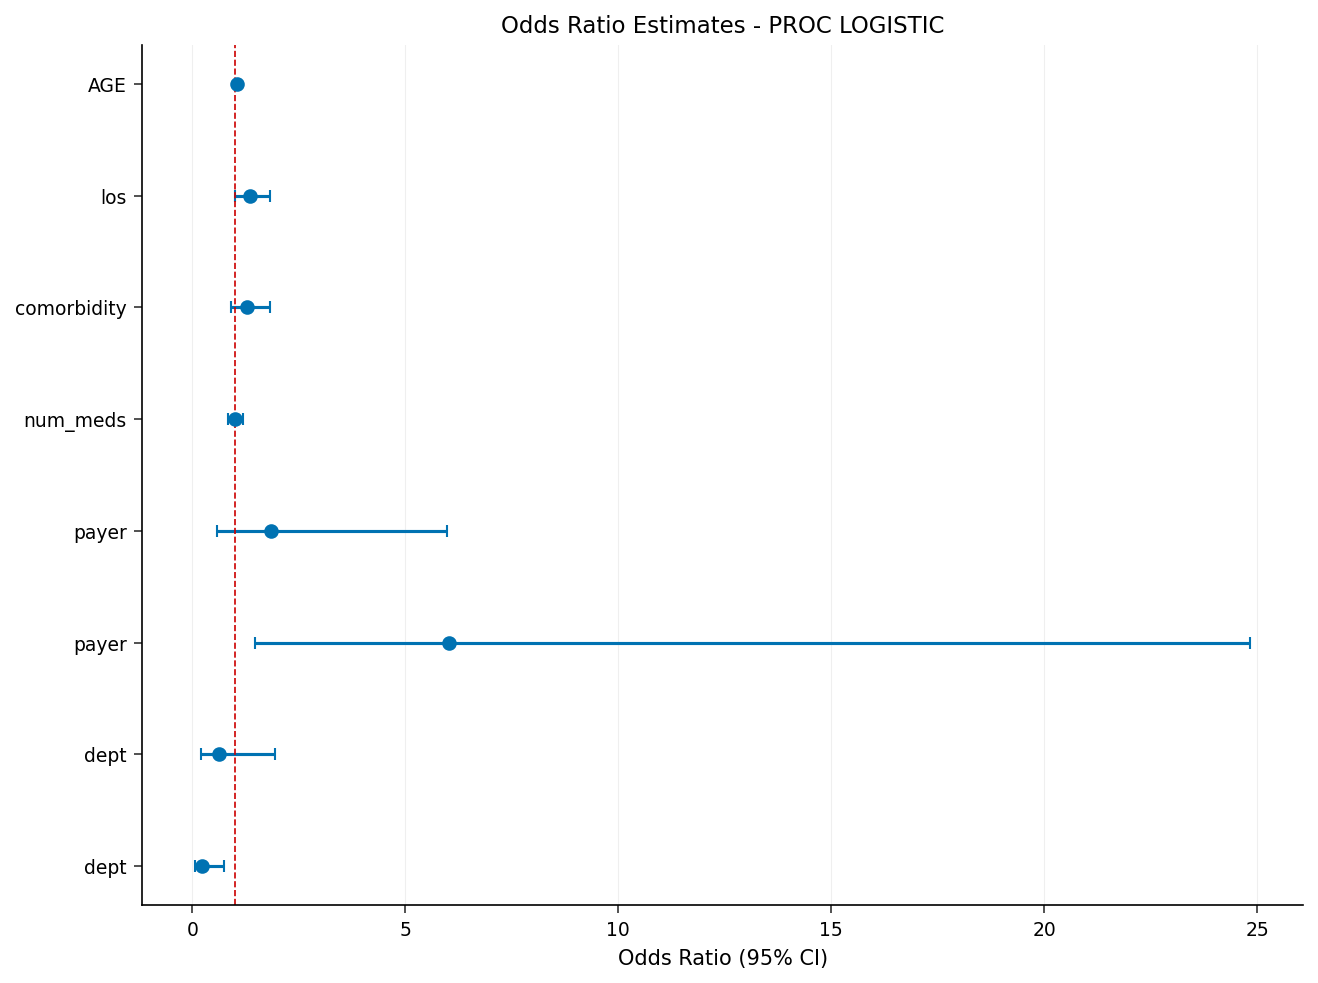

In [3]:
ODS ΕΞΟΔΟΣ ParameterEstimates=pe;
ΔΙΑΔΙΚΑΣΙΑ LOGISTIC ΔΕΔΟΜΕΝΑ=encounters PLOTS(only)=oddsratio;
    ΚΛΑΣΗ payer dept / PARAM=REF REF=first;
    ΜΟΝΤΕΛΟ readmit(EVENT='1') = AGE los comorbidity num_meds payer dept
          / clodds=wald rsquare lackfit;
    units AGE=10 los=5;
    oddsratio comorbidity / cl=wald;
ΕΚΤΕΛΕΣΗ;
ODS ΕΞΟΔΟΣ CLOSE;

## Βήμα 4 — Καταγραφή των προσαρμοσμένων συντελεστών

Τα γραφήματα επίδρασης βασισμένα σε μοντέλο που ακολουθούν κατασκευάζονται απευθείας από τους *προσαρμοσμένους* συντελεστές, επομένως συμφωνούν πάντα με το μοντέλο στο Βήμα 3. Αποθηκεύσαμε τις εκτιμήσεις παραμέτρων με `ODS OUTPUT ParameterEstimates=pe`· εδώ αναδιπλώνουμε αυτόν τον μακρύ πίνακα σε ένα σύνολο δεδομένων `params` μίας γραμμής (μία μεταβλητή ανά συντελεστή) και προσαρτούμε τους μέσους όρους της κοόρτης για τις συνεχείς προβλεπτικές μεταβλητές. Η διατήρηση των μη εστιαζόμενων προβλεπτικών μεταβλητών στους μέσους όρους τους είναι ακριβώς αυτό που κάνει εσωτερικά ένα EFFECTPLOT — επιτρέπει σε κάθε γράφημα να μεταβάλλει έναν παράγοντα διατηρώντας τους υπόλοιπους σταθερούς σε ένα αντιπροσωπευτικό προφίλ.

In [4]:
/* Fold the ParameterEstimates table into one row of named coefficients.
   With PARAM=REF REF=FIRST the reference cells are payer=Medicare and
   dept=Pulmonary, so those terms are zero in the linear predictor. */
ΔΕΔΟΜΕΝΑ coefs;
    RETAIN b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen 0;
    ΟΡΙΣΜΟΣ pe ΤΕΛΟΣ=last;
    var = upcase(strip(Variable));
    cv  = strip(ClassVal0);
    ΕΑΝ var='INTERCEPT' ΤΟΤΕ b0 = ESTIMATE;
    ΑΛΛΙΩΣ ΕΑΝ var='AGE' ΤΟΤΕ b_age = ESTIMATE;
    ΑΛΛΙΩΣ ΕΑΝ var='LOS' ΤΟΤΕ b_los = ESTIMATE;
    ΑΛΛΙΩΣ ΕΑΝ var='COMORBIDITY' ΤΟΤΕ b_com = ESTIMATE;
    ΑΛΛΙΩΣ ΕΑΝ var='NUM_MEDS' ΤΟΤΕ b_med = ESTIMATE;
    ΑΛΛΙΩΣ ΕΑΝ var='PAYER' AND cv='Medicaid'   ΤΟΤΕ b_pmcaid = ESTIMATE;
    ΑΛΛΙΩΣ ΕΑΝ var='PAYER' AND cv='Commercial' ΤΟΤΕ b_pcomm  = ESTIMATE;
    ΑΛΛΙΩΣ ΕΑΝ var='DEPT'  AND cv='Cardiology' ΤΟΤΕ b_dcard  = ESTIMATE;
    ΑΛΛΙΩΣ ΕΑΝ var='DEPT'  AND cv='General'    ΤΟΤΕ b_dgen   = ESTIMATE;
    ΕΑΝ last ΤΟΤΕ ΕΞΟΔΟΣ;
    ΚΡΑΤΗΣΗ b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen;
ΕΚΤΕΛΕΣΗ;

/* Cohort means of the continuous covariates, held fixed in the plots. */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=encounters NOPRINT;
    ΜΕΤΑΒΛΗΤΗ AGE los comorbidity num_meds;
    ΕΞΟΔΟΣ out=mn mean=m_age m_los m_com m_med;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ params;
    ΣΥΓΧΩΝΕΥΣΗ coefs mn;
    ΚΡΑΤΗΣΗ b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
         m_age m_los m_com m_med;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=params noobs;
    TITLE "Προσαρμοσμένοι συντελεστές και μέσοι συμμεταβλητών για τα διαγράμματα επίδρασης";
ΕΚΤΕΛΕΣΗ;

                    Προσαρμοσμένοι συντελεστές και μέσοι συμμεταβλητών για τα διαγράμματα επίδρασης                     

           b0         b_age         b_los         b_com         b_med      b_pmcaid       b_pcomm        b_dcard         b_dgen  m_age  m_los  m_com  m_med
-4.9220021175  0.0443054038  0.3052368368  0.2553476408  0.0005084625  1.7958084904  0.6128310257  -0.4493317481  -1.4957988173  70.53   4.59   2.88   7.08




NOTE: DATA coefs


NOTE: Read 9 rows from pe.
NOTE: Wrote coefs (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mn has 1 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA params

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=params

NOTE: PROC PRINT completed: 1 observations printed, 13 variables


## Βήμα 5 — Γράφημα προσαρμογής: πιθανότητα επανεισαγωγής έναντι διάρκειας νοσηλείας

Το απλούστερο γράφημα επίδρασης είναι μια **καμπύλη προσαρμογής**: η προβλεπόμενη πιθανότητα επανεισαγωγής έναντι μίας μόνο συνεχούς συμμεταβλητής, με τις υπόλοιπες προβλεπτικές μεταβλητές διατηρημένες σε ένα αντιπροσωπευτικό προφίλ. Κατασκευάζουμε ένα πλέγμα διάρκειας νοσηλείας (1–18 ημέρες), αποτιμούμε τον προσαρμοσμένο γραμμικό προβλέπτη σε κάθε τιμή για έναν ασθενή **καρδιολογίας με Medicare** (ηλικία, συννοσηρότητα και πλήθος φαρμάκων κατά το εξιτήριο καθηλωμένα στους μέσους όρους της κοόρτης από το Βήμα 4), εφαρμόζουμε το αντίστροφο logit, και σχεδιάζουμε την καμπύλη στην κλίμακα της πιθανότητας με το PROC SGPLOT.

                    Προσαρμοσμένοι συντελεστές και μέσοι συμμεταβλητών για τα διαγράμματα επίδρασης                     




NOTE: DATA grid_los


NOTE: Wrote grid_los (18 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_los


NOTE: Read 18 rows from grid_los.
NOTE: Wrote fit_los (18 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_los

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


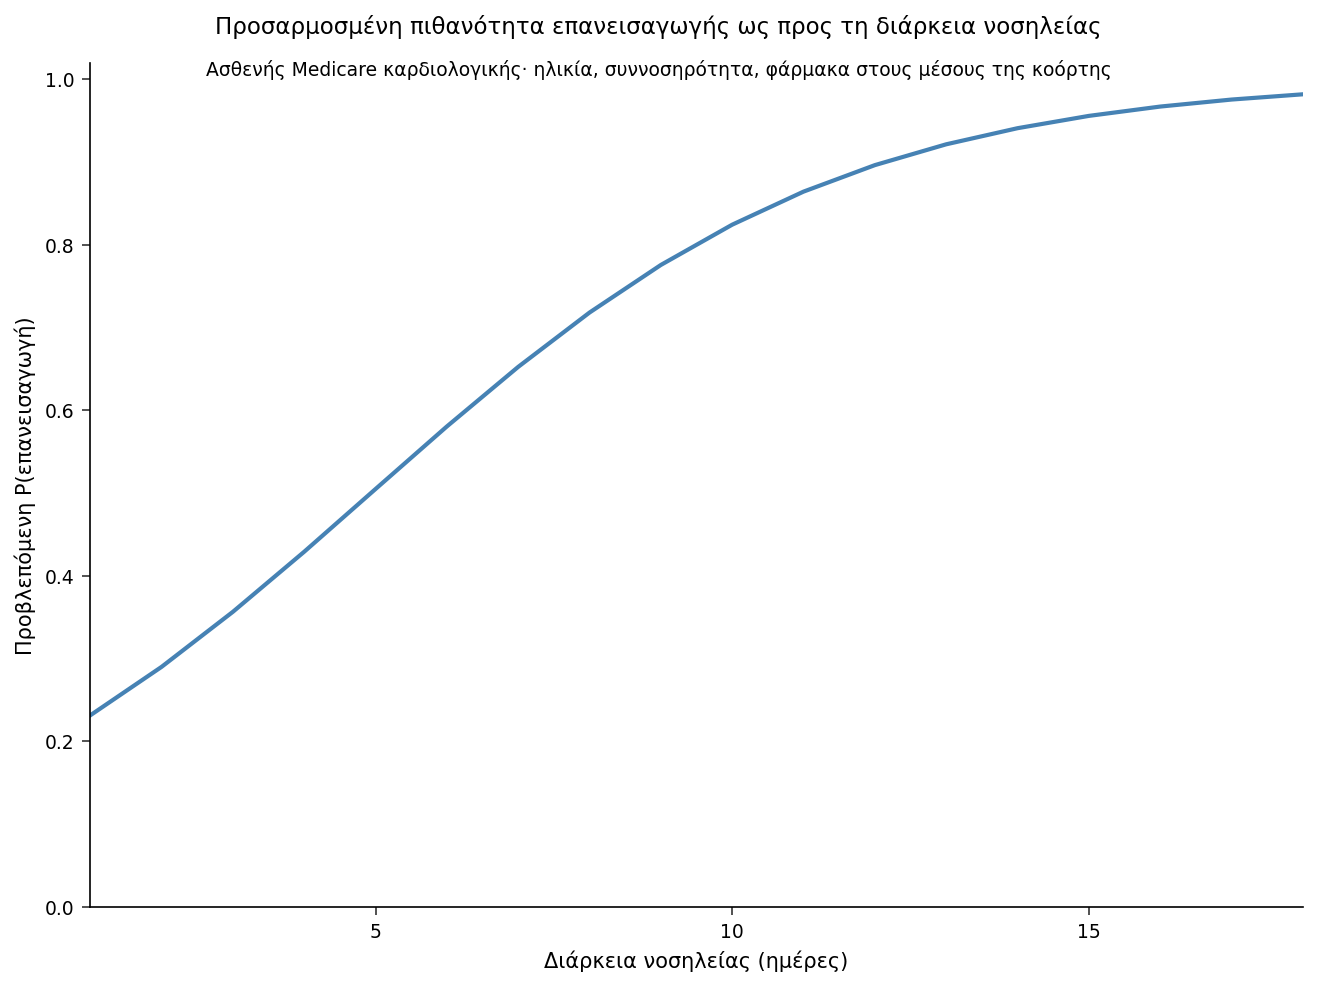

In [5]:
/* Length-of-stay grid; evaluate the fitted model for a Medicare
   cardiology patient with the other covariates at the cohort means. */
ΔΕΔΟΜΕΝΑ grid_los;
    ΕΠΑΝΑΛΗΨΗ los = 1 ΕΩΣ 18;
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ fit_los;
    ΟΡΙΣΜΟΣ grid_los;
    ΕΑΝ _n_ = 1 ΤΟΤΕ ΟΡΙΣΜΟΣ params;
    RETAIN b0 b_age b_los b_com b_med b_dcard m_age m_com m_med;
    /* Medicare payer is the reference (term = 0); Cardiology adds b_dcard */
    xb = b0 + b_age*m_age + b_los*los + b_com*m_com + b_med*m_med + b_dcard;
    phat = 1 / (1 + EXP(-xb));
    ΚΡΑΤΗΣΗ los phat;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=fit_los;
    SERIES x=los y=phat / LINEATTRS=(thickness=2 color=steelblue);
    TITLE  "Προσαρμοσμένη πιθανότητα επανεισαγωγής ως προς τη διάρκεια νοσηλείας";
    title2 "Ασθενής Medicare καρδιολογικής· ηλικία, συννοσηρότητα, φάρμακα στους μέσους της κοόρτης";
    XAXIS ΕΤΙΚΕΤΑ="Διάρκεια νοσηλείας (ημέρες)";
    YAXIS ΕΤΙΚΕΤΑ="Προβλεπόμενη P(επανεισαγωγή)" VALUES=(0 ΕΩΣ 1 ΚΑΤΑ 0.2);
ΕΚΤΕΛΕΣΗ;

## Βήμα 6 — Τμηματική προσαρμογή: κίνδυνος έναντι ηλικίας, στρωματοποιημένος ανά ασφαλιστικό φορέα

Μια **τμηματική προσαρμογή** σχεδιάζει μία προσαρμοσμένη καμπύλη ανά επίπεδο μιας επίδρασης ταξινόμησης — ιδανική για να δείξει πώς το μείγμα ασφαλιστικών φορέων μετατοπίζει την κλίση ηλικίας–κινδύνου. Επεκτείνουμε το πλέγμα στην `age` (30–95) διασταυρωμένη με τους τρεις ασφαλιστικούς φορείς, αποτιμούμε το προσαρμοσμένο μοντέλο για έναν ασθενή Καρδιολογίας (διάρκεια νοσηλείας, συννοσηρότητα και φάρμακα στους μέσους όρους της κοόρτης), και επιθέτουμε τις τρεις καμπύλες πιθανότητας με `GROUP=payer`.

                    Προσαρμοσμένοι συντελεστές και μέσοι συμμεταβλητών για τα διαγράμματα επίδρασης                     




NOTE: DATA grid_age


NOTE: Wrote grid_age (42 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_age


NOTE: Read 42 rows from grid_age.
NOTE: Wrote fit_age (42 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_age

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


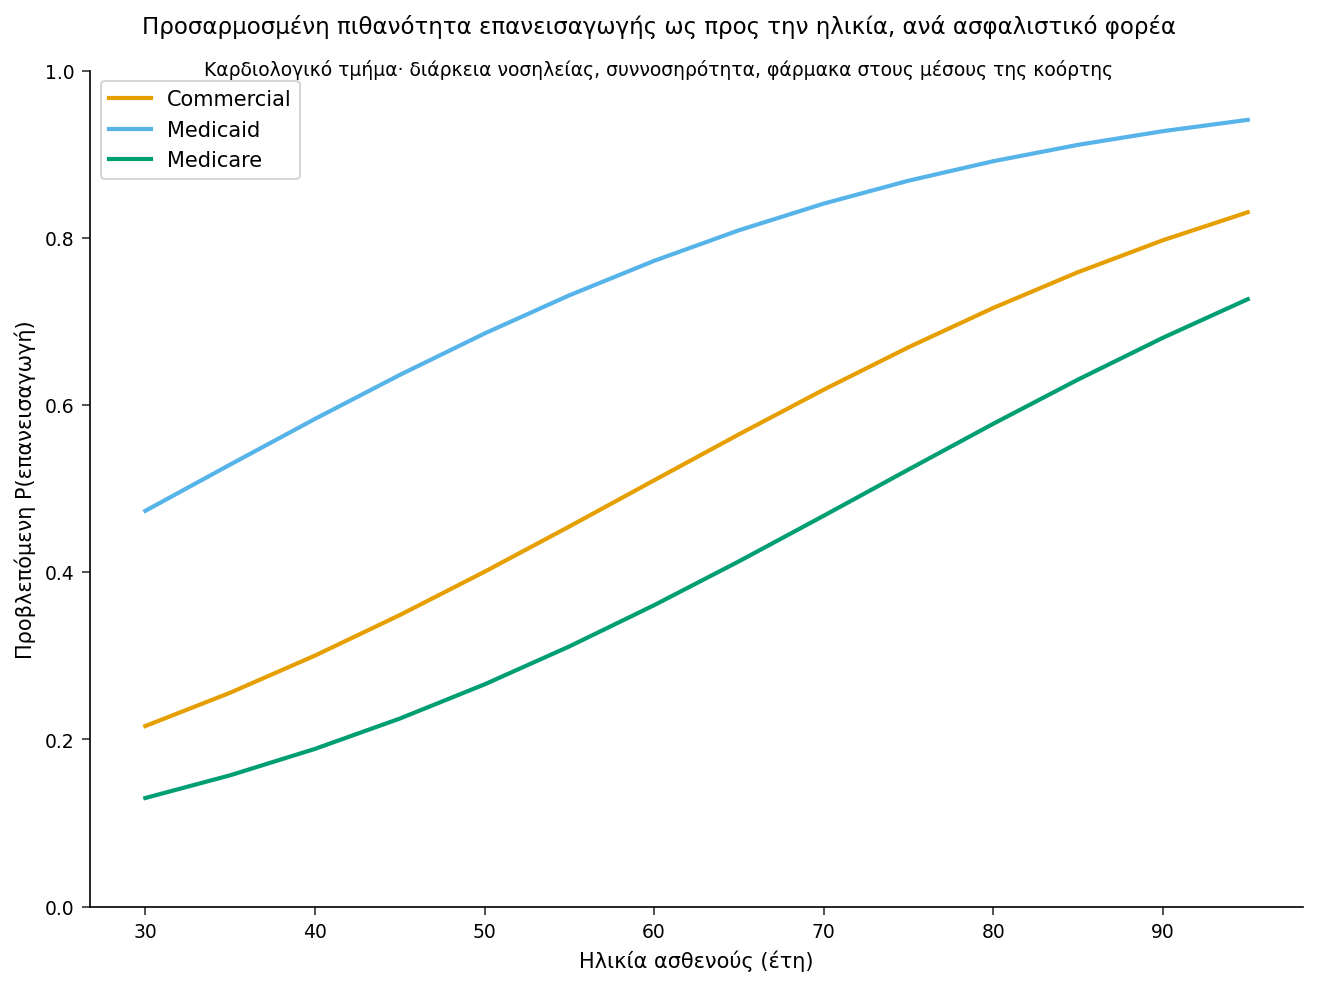

In [6]:
/* Age x payer grid for a Cardiology patient; other covariates at means. */
ΔΕΔΟΜΕΝΑ grid_age;
    LENGTH payer $12;
    ΕΠΑΝΑΛΗΨΗ payer = 'Medicare', 'Medicaid', 'Commercial';
        ΕΠΑΝΑΛΗΨΗ AGE = 30 ΕΩΣ 95 ΚΑΤΑ 5;
            ΕΞΟΔΟΣ;
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ fit_age;
    ΟΡΙΣΜΟΣ grid_age;
    ΕΑΝ _n_ = 1 ΤΟΤΕ ΟΡΙΣΜΟΣ params;
    RETAIN b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard
           m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    xb = b0 + b_age*AGE + b_los*m_los + b_com*m_com + b_med*m_med
         + b_dcard + pay_term;
    phat = 1 / (1 + EXP(-xb));
    ΚΡΑΤΗΣΗ payer AGE phat;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=fit_age;
    SERIES x=AGE y=phat / GROUP=payer LINEATTRS=(thickness=2);
    TITLE  "Προσαρμοσμένη πιθανότητα επανεισαγωγής ως προς την ηλικία, ανά ασφαλιστικό φορέα";
    title2 "Καρδιολογικό τμήμα· διάρκεια νοσηλείας, συννοσηρότητα, φάρμακα στους μέσους της κοόρτης";
    XAXIS ΕΤΙΚΕΤΑ="Ηλικία ασθενούς (έτη)";
    YAXIS ΕΤΙΚΕΤΑ="Προβλεπόμενη P(επανεισαγωγή)" VALUES=(0 ΕΩΣ 1 ΚΑΤΑ 0.2);
    keylegend / location=inside position=topleft ACROSS=1;
ΕΚΤΕΛΕΣΗ;

## Βήμα 7 — Γράφημα αλληλεπίδρασης: κλινική ανά ασφαλιστικό φορέα

Για να συγκρίνουμε τον προβλεπόμενο κίνδυνο σε αμφότερες τις επιδράσεις ταξινόμησης ταυτόχρονα, διασταυρώνουμε το `dept` με το `payer` (εννέα συνδυασμοί), αποτιμούμε το προσαρμοσμένο μοντέλο με κάθε συνεχή συμμεταβλητή στον μέσο όρο της κοόρτης της, και σχεδιάζουμε ένα ομαδοποιημένο ραβδόγραμμα με το `dept` στον άξονα X και τον ασφαλιστικό φορέα ως ομαδοποίηση. Επειδή αυτό το μοντέλο δεν έχει όρο αλληλεπίδρασης κλινικής-ανά-ασφαλιστικό φορέα, η διάταξη των ασφαλιστικών φορέων είναι η ίδια προσθετική μετατόπιση εντός κάθε κλινικής — το γράφημα καθιστά αυτή την προσθετικότητα ορατή με μια ματιά, παράλληλα με την κατάταξη των κλινικών.

                    Προσαρμοσμένοι συντελεστές και μέσοι συμμεταβλητών για τα διαγράμματα επίδρασης                     




NOTE: DATA grid_dx


NOTE: Wrote grid_dx (9 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_dx


NOTE: Read 9 rows from grid_dx.
NOTE: Wrote fit_dx (9 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_dx

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


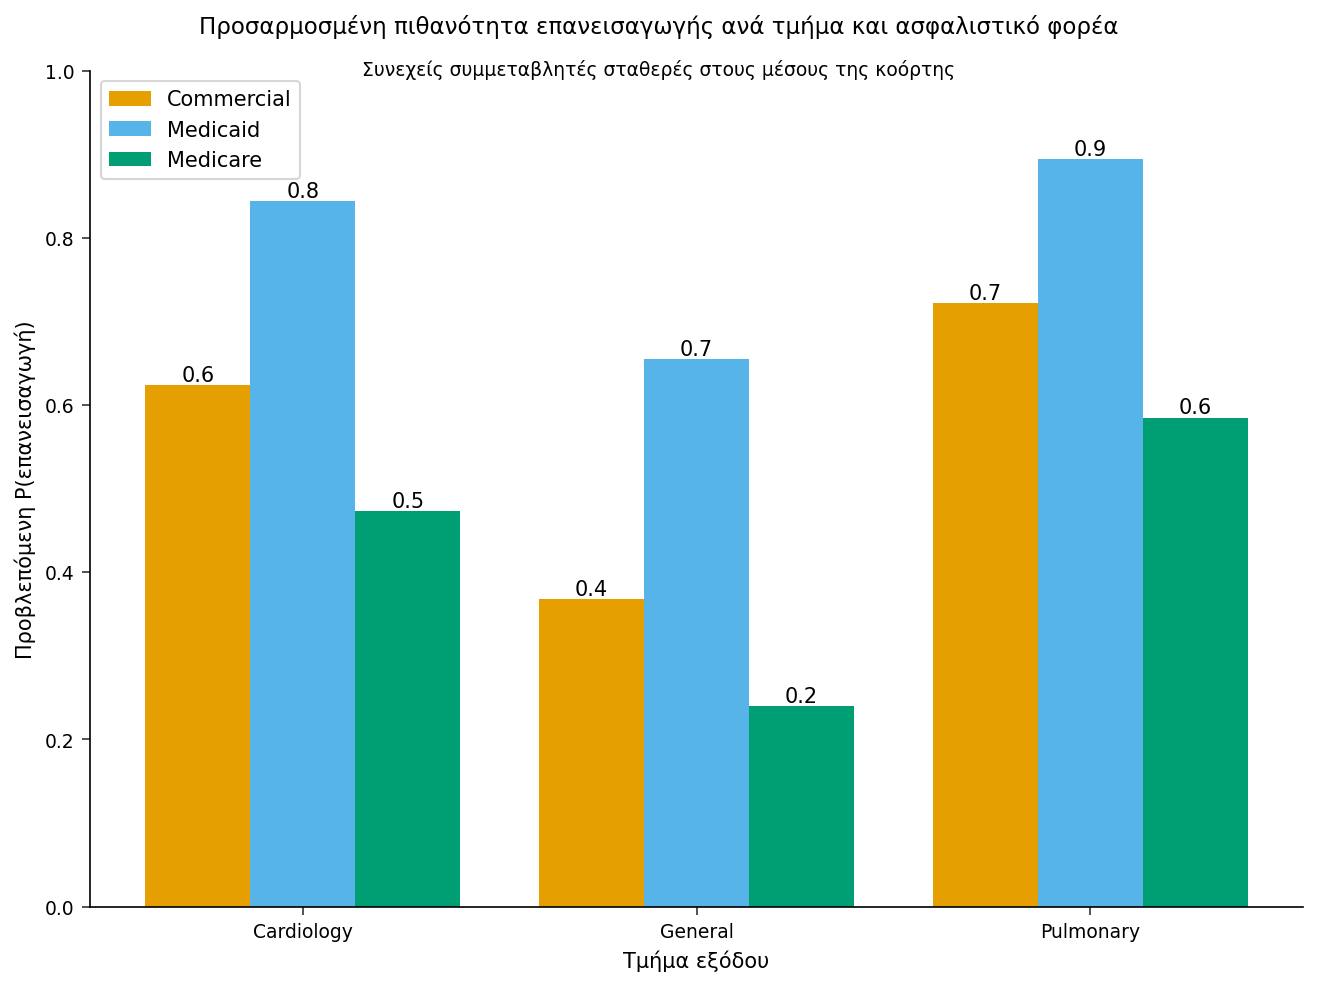

In [7]:
/* Department x payer grid; all continuous covariates at cohort means. */
ΔΕΔΟΜΕΝΑ grid_dx;
    LENGTH dept $12 payer $12;
    ΕΠΑΝΑΛΗΨΗ dept = 'Cardiology', 'Pulmonary', 'General';
        ΕΠΑΝΑΛΗΨΗ payer = 'Medicare', 'Medicaid', 'Commercial';
            ΕΞΟΔΟΣ;
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ fit_dx;
    ΟΡΙΣΜΟΣ grid_dx;
    ΕΑΝ _n_ = 1 ΤΟΤΕ ΟΡΙΣΜΟΣ params;
    RETAIN b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
           m_age m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    dep_term = (dept='Cardiology')*b_dcard + (dept='General')*b_dgen;
    xb = b0 + b_age*m_age + b_los*m_los + b_com*m_com + b_med*m_med
         + pay_term + dep_term;
    phat = 1 / (1 + EXP(-xb));
    ΚΡΑΤΗΣΗ dept payer phat;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=fit_dx;
    VBAR dept / RESPONSE=phat GROUP=payer GROUPDISPLAY=CLUSTER
                DATALABEL datalabelattrs=(size=8);
    TITLE  "Προσαρμοσμένη πιθανότητα επανεισαγωγής ανά τμήμα και ασφαλιστικό φορέα";
    title2 "Συνεχείς συμμεταβλητές σταθερές στους μέσους της κοόρτης";
    XAXIS ΕΤΙΚΕΤΑ="Τμήμα εξόδου";
    YAXIS ΕΤΙΚΕΤΑ="Προβλεπόμενη P(επανεισαγωγή)" VALUES=(0 ΕΩΣ 1 ΚΑΤΑ 0.2);
ΕΚΤΕΛΕΣΗ;

## Βήμα 8 — Ερμηνεία των αποτελεσμάτων

Τα γραφήματα επίδρασης μετατρέπουν το προσαρμοσμένο μοντέλο PROC LOGISTIC σε εικόνες στην κλίμακα της πιθανότητας που αντιστοιχούν σε αποφάσεις διαχείρισης φροντίδας:

- **Διάρκεια νοσηλείας (καμπύλη προσαρμογής).** Για έναν ασθενή καρδιολογίας με Medicare στους μέσους όρους της κοόρτης, η προβλεπόμενη πιθανότητα επανεισαγωγής αυξάνεται από περίπου **0.23 σε νοσηλεία 1 ημέρας σε περίπου 0.82 στις 10 ημέρες και ~0.98 στις 18 ημέρες** — το απότομο μέσο της λογιστικής καμπύλης. Αυτό είναι το ίδιο σήμα με τον λόγο πιθανοτήτων διάρκειας νοσηλείας **1.36 ανά ημέρα** (το `UNITS los=5` το αναπροσαρμόζει σε βήμα πέντε ημερών), και επισημαίνει τις μακρές νοσηλείες ως συγκεκριμένο έναυσμα για ένταξη σε μεταβατική φροντίδα.
- **Ηλικία και ασφαλιστικός φορέας (τμηματική προσαρμογή).** Ο κίνδυνος αυξάνεται μονότονα με την ηλικία σε κάθε ασφαλιστικό φορέα, και οι τρεις καμπύλες δεν τέμνονται ποτέ: η καμπύλη **Medicaid** βρίσκεται ψηλότερα σε κάθε δεδομένη ηλικία, η **Commercial** στη μέση, και η **Medicare** χαμηλότερα — συνεπές με τους προσαρμοσμένους λόγους πιθανοτήτων ασφαλιστικών φορέων (Medicaid 6.02, Commercial 1.85, αμφότεροι σε σχέση με το Medicare). Το χάσμα είναι μεγαλύτερο στις νεότερες ηλικίες και στενεύει καθώς όλοι πλησιάζουν σε υψηλή πιθανότητα, στρέφοντας την προσοχή της διαχείρισης φροντίδας σε νεότερους ασθενείς Medicaid που διαφορετικά θα φαίνονταν χαμηλού κινδύνου.
- **Κλινική και ασφαλιστικός φορέας (γράφημα αλληλεπίδρασης).** Η **Pulmonary** φέρει την υψηλότερη προβλεπόμενη πιθανότητα επανεισαγωγής σε κάθε ομάδα ασφαλιστικού φορέα, η **Cardiology** είναι ενδιάμεση, και η **General medicine** χαμηλότερη (οι προσαρμοσμένοι λόγοι πιθανοτήτων κλινικών είναι 0.64 για την Cardiology και 0.22 για την General, σε σχέση με την Pulmonary). Επειδή το μοντέλο δεν έχει όρο αλληλεπίδρασης κλινικής-ανά-ασφαλιστικό φορέα, η διάταξη των ασφαλιστικών φορέων είναι η ίδια προσθετική μετατόπιση εντός κάθε κλινικής — οι ράβδοι ανεβαίνουν με την ίδια σειρά Medicaid > Commercial > Medicare σε κάθε κλινική.

**Συμπέρασμα:** αντί να ζητάμε από τους κλινικούς να ερμηνεύσουν συντελεστές log-odds, τα γραφήματα επίδρασης βασισμένα σε μοντέλο παρουσιάζουν το προσαρμοσμένο μοντέλο επανεισαγωγής ως εικόνες στην κλίμακα της πιθανότητας — ποιους να εντάξουν σε παρακολούθηση μεταβατικής φροντίδας, και ποιες κλινικές και πληθυσμούς ασφαλιστικών φορέων να θέσουν σε προτεραιότητα. Το SAS τα παράγει απευθείας μέσω του `EFFECTPLOT`· εδώ ανακατασκευάσαμε τις πανομοιότυπες καμπύλες από τους προσαρμοσμένους συντελεστές ώστε το παράδειγμα να τρέχει από άκρη σε άκρη σήμερα.